# Derivatives

Randomly changing and searching for optimal weights and biases did not prove fruitful for one 
main reason: the number of possible combinations of weights and biases is infinite, and we need 
something smarter than pure luck to achieve any success. Each weight and bias may also have 
different degrees of influence on the loss — this influence depends on the parameters themselves 
as well as on the current sample, which is an input to the first layer. These input values are then 
multiplied by the weights, so the input data affects the neuron’s output and affects the impact that 
the weights make on the loss. The same principle applies to the biases and parameters in the next 
layers, taking the previous layer’s outputs as inputs. This means that the impact on the output 
values depends on the parameters as well as the samples — which is why we are calculating the 
loss value per each sample separately. Finally, the function of ​ how​ a weight or bias impacts the 
overall loss is not necessarily linear. In order to know ​ how​ to adjust weights and biases, we first 
need to understand their impact on the loss. 

# The Impact of a Parameter on the Output

Let’s start with a simple function and discover what is meant by “impact.” 
A very simple function ​ y=2x​, which takes ​ x​ as an input:

``` python

def f(x):
    return 2*x
```

Now let’s create some code around this to visualize the data — we’ll import NumPy and 
Matplotlib, create an array of 5 input values from 0 to 4, calculate the function output for each 
of these input values, and plot the result as lines between consecutive points. These points’ 
coordinates are inputs as ​ x​ and function outputs as ​ y​:

``` python

import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return 2*x

X = np.array(range(5))
y = f(x)

print(X)
print(y)
```

[0 1 2 3 4]
[0 2 4 6 8]


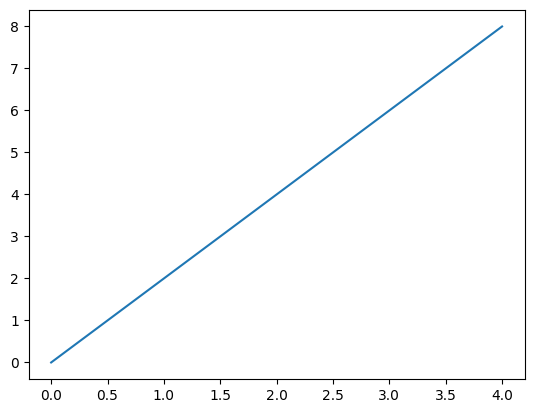

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return 2*x

X = np.array(range(5))
y = f(X)

print(X)
print(y)

plt.plot(X,y)
plt.show()

# The Slope 
This looks like an output of the ​ f(x) = 2x​ function, which is a line. How might you define the 
impact​ that ​ x​ will have on ​ y​? Some will say, ​ “y ​ is double ​ x​” Another way to describe the ​ impact 
of a linear function such as this comes from algebra: the ​ slope
. “Rise over run” might be a phrase 
you recall from school. The slope of a line is: 

"will use Claude to write it here , although it is 
Change in y / Change in X
"

It is change in ​ y​ divided by change in ​ x,​ or, in math — ​ delta y​ divided by ​ delta x​. What’s the slope 
of ​ f(x) = 2x​ then? 
To calculate the slope, first we have to take any two points lying on the function’s graph and 
subtract them to calculate the change. Subtracting the points means to subtract their x and y 
dimensions respectively.


Continuing the code, we keep all values of ​ x​ in a single-dimensional NumPy array, ​ x​, and all 
results in a single-dimensional array, ​ y​. To perform the same operation, we’ll take ​ x[​0​]​ and 
y[​0​]​ for the first point, then ​ x[​1​]​ and ​ y[​1​]​ for the second one. Now we can calculate the slope 
between them: 

In [2]:
print(y[1]-y[0] / X[1]-X[0])

2.0


It is not surprising that the slope of this line is 2. We could say the measure of the impact that ​ x 
has on ​ y​ is 2. We can calculate the slope in the same way for any linear function, including linear 
functions that aren’t as obvious. 
What about a nonlinear function like ​ f(x)=2x​2 ​?

```python

def f(x):
    return 2*x**2
```

In [3]:
def f(x):
    return 2*x**2

y = f(X)

print(X)
print(y)

[0 1 2 3 4]
[ 0  2  8 18 32]


Now for the first pair of points: 

In [4]:
print((y[1] - y[0]) / (X[1] - X[0]))

2.0


In [5]:
# And for another !!

print((y[3] - y[2] * (X[3] - X[2])))

10


In [7]:
p2_delta = 0.0001

x1 = 1
x2 = x1 + p2_delta

y1 = f(x1)
y2 = f(x2)

approximate_derivative = (y2-y1) / (x2-x1)
print(approximate_derivative)

4.0001999999987845


Continuing with ​ numerical differentiation
, let us visualize the tangent lines and how they 
change depending on where we calculate them. To begin, we’ll make the graph of this function 
more granular using Numpy’s ​ arange()​, ​ allowing us to plot with smaller steps. The 
np.arange()​ ​ function takes in ​ start, stop, ​ and ​ step​ parameters, allowing us to take fractions of a 
step, such as ​ 0.001​ at a time: 

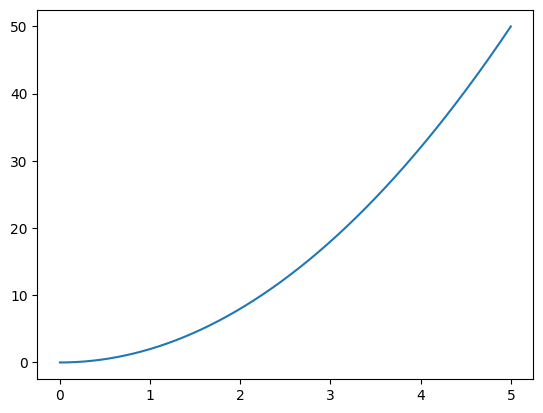

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return 2*x**2

# np.arange(start, stop, step)
x = np.arange(0, 5, 0.001)
y = f(x)

plt.plot(x,y)
plt.show()

To calculate ​ b,​ the formula is ​ b = y - mx​:

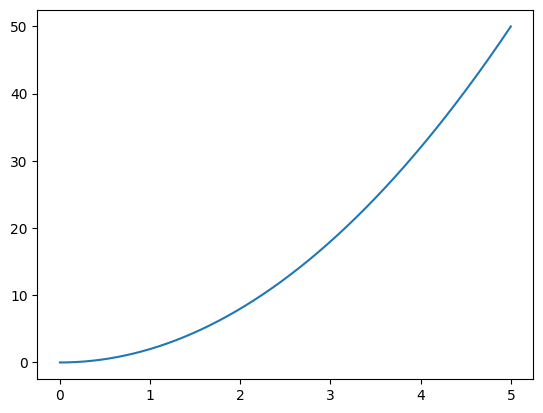

(2, 8) (2.0001, 8.000800020000002)
Approximate derivative for f(x) where x = 2 is 8.000199999998785


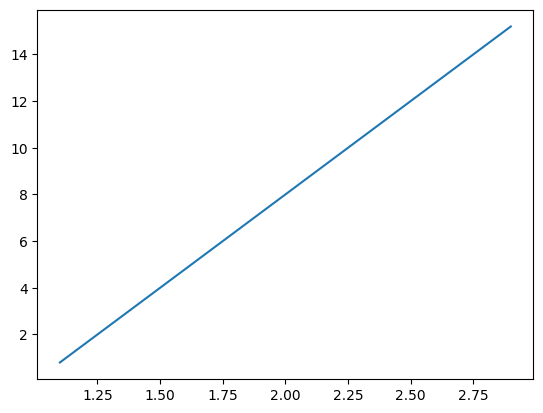

In [10]:
import matplotlib.pyplot as plt
import numpy as np


def f(x):
    return 2*x**2

x = np.arange(0, 5, 0.001)
y = f(x)

plt.plot(x, y)
plt.show()

p2_delta = 0.0001

x1 = 2
x2 = x1 + p2_delta

y1 = f(x1)
y2 = f(x2)

print((x1, y1), (x2, y2))

approximate_derivative = (y2-y1) / (x2-x1)
b = y2 - approximate_derivative*x2

def tangent_line(x):
    return approximate_derivative*x + b
to_plot = [x1-0.9, x1, x1+0.9]
plt.plot(to_plot, [tangent_line(i) for i in to_plot])


print("Approximate derivative for f(x)",
      f'where x = {x1} is {approximate_derivative}')
plt.show()

The orange line is the approximate tangent line at ​ x=2​ for the function ​ f(x) = 2x​2​. Why do we care 
about this? You will soon find that we care only about the ​ slope​ of this tangent line but both 
visualizing and understanding the ​ tangent line
 are very important. We care about the slope of the 
tangent line because it informs us about the ​ impact​ that ​ x​ has on this function at a particular point, 
referred to as the ​ instantaneous rate of change
. We will use this concept to determine the effect 
of a specific weight or bias on the overall loss function given a sample. For now, with different 
values for ​ x​, we can observe resulting impacts on the function. We can continue the previous code 
to see the tangent line for various inputs (​x)​ - we put a part of the code in a loop over example ​ x 
values and plot multiple tangent lines: 

Points: (0, 0), (0.0001, 2e-08)
Approximate derivative for f(x) where x = 0 is 0.0002
Points: (1, 2), (1.0001, 2.00040002)
Approximate derivative for f(x) where x = 1 is 4.0002
Points: (2, 8), (2.0001, 8.000800020000002)
Approximate derivative for f(x) where x = 2 is 8.0002
Points: (3, 18), (3.0001, 18.001200020000002)
Approximate derivative for f(x) where x = 3 is 12.0002
Points: (4, 32), (4.0001, 32.00160002)
Approximate derivative for f(x) where x = 4 is 16.0002


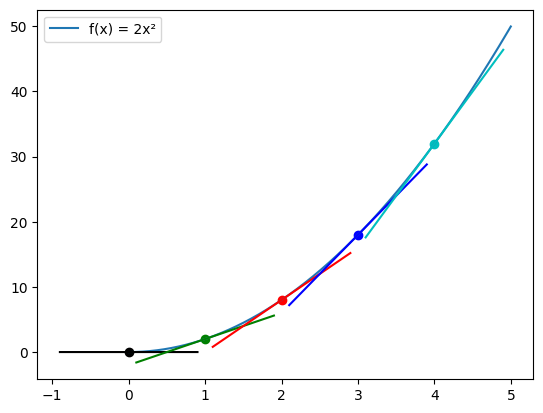

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return 2 * x**2

# Create x and y data for the function curve
x = np.arange(0, 5, 0.001)          # np.arange already returns an array
y = f(x)

# Plot the function
plt.plot(x, y, label='f(x) = 2x²')

colors = ['k', 'g', 'r', 'b', 'c']

def approximate_tangent_line(x, approximate_derivative, b):
    return approximate_derivative * x + b

for i in range(5):
    p2_delta = 0.0001
    x1 = i
    x2 = x1 + p2_delta

    y1 = f(x1)
    y2 = f(x2)

    print(f"Points: ({x1}, {y1}), ({x2}, {y2})")

    approximate_derivative = (y2 - y1) / (x2 - x1)
    b = y2 - approximate_derivative * x2

    # Points to draw the tangent line segment
    to_plot = [x1 - 0.9, x1, x1 + 0.9]

    plt.scatter(x1, y1, c=colors[i])
    plt.plot(to_plot,
             [approximate_tangent_line(pt, approximate_derivative, b) for pt in to_plot],
             c=colors[i])

    print(f"Approximate derivative for f(x) where x = {x1} is {approximate_derivative:.4f}")

# Show everything together
plt.legend()
plt.show()